   493782  164
0  572059   43
1  608827   98
2  626932  101
3  642200  100
4  754844  197
[STOP] mejora muy pequeña en iter 1605
Best solution (norm): 1.0252485836137448, 0.042427022550663857
Best fitness (MSE norm): 0.006962539179483915


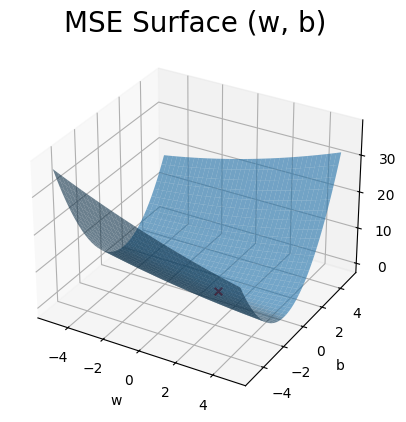

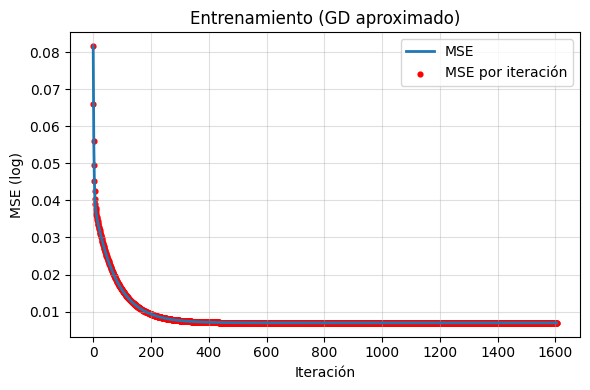

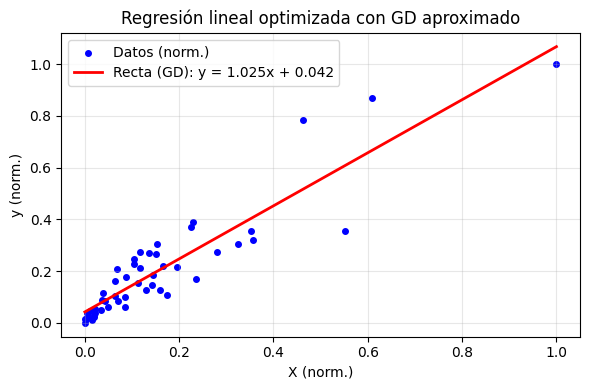

In [9]:
#######################################################################################
# Práctica 4: Regresión lineal con GD "aproximado" (gradiente numérico)
# Authors: Jorge Gálvez, UdG | Mod.: Christian Luna, UdG
#######################################################################################

# Import required libraries.
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

## Cargamos los datos 
# (Datos = el mapa del cuarto que vamos a recorrer buscando las llaves)
url = "https://raw.githubusercontent.com/ChristianLuna1/tesis-maestria/refs/heads/main/Machine_Learning/DatosPractica1CLuna.csv"
df = pd.read_csv(url)

# Definimos X e y (normalizados a [0,1] para estabilidad del GD y comparabilidad)
# (Normalizar = ajustar la escala del cuarto para que cada paso tenga un efecto razonable
#  en todas las direcciones; evitamos pasos gigantes o microscópicos)
X_raw = df.iloc[:, 0].astype(float).values   # primera columna
y_raw = df.iloc[:, 1].astype(float).values   # segunda columna

Xmin, Xmax = X_raw.min(), X_raw.max()
ymin, ymax = y_raw.min(), y_raw.max()
X = (X_raw - Xmin) / (Xmax - Xmin)
y = (y_raw - ymin) / (ymax - ymin)

print(df.head())
# -----------------------------

# Función de pérdida (MSE) para un vector de parámetros x = [[w, b]]
# (Aquí definimos la "altura del piso" en cada punto (w,b):
#  cuanto más pequeño el MSE, más cerca estamos de las llaves)
def sphere(x):
    w, b = x[0, 0], x[0, 1]
    y_hat = w * X + b                  # recta actual = nuestra posición estimada
    fit = np.mean((y - y_hat) ** 2)    # MSE = altura del piso (qué tan lejos de las llaves)
    return fit

# Nº de variables de decisión
# (Tenemos dos direcciones para caminar en el cuarto: w y b)
dimensions = 2

# Límites del espacio de búsqueda (para acotar w y b durante el GD)
# (Paredes del cuarto: no dejamos que w o b se salgan de [-5,5])
t = np.array([-5, 5])
f_range = np.tile(t, (dimensions, 1))

# Iteraciones máximas del optimizador
# (Máximo número de pasos que daremos buscando las llaves)
max_iter = 5000  # más iteraciones para GD

# ========= Inicialización para GD aproximado =========
# Punto inicial (centrado) y tasa de aprendizaje
# (Empezamos en el centro del cuarto. alpha = tamaño del paso.
#  delta = toquecito para "palpar" la pendiente en cada dirección)
theta = np.zeros(dimensions, dtype=float)   # [w, b] = [0, 0]
alpha = 0.1                                 # tamaño de cada paso por el piso
delta = 1e-6                                # toquecito para estimar pendiente (gradiente numérico)

best_position = theta.copy()                # mejor lugar encontrado (posibles llaves)
best_fitness = sphere(np.array([theta]))    # altura en el mejor lugar (MSE mínimo visto)
score_history = [best_fitness]              # bitácora: altura en cada paso

# -------- Superficie MSE (para visualizar w,b) --------
# (Dibujamos el relieve del piso en 3D: ejes w y b, altura = MSE(w,b).
#  La X roja será nuestra posición conforme caminamos.)
xGraph = np.linspace(f_range[0, 0], f_range[0, 1], 40)
yGraph = np.linspace(f_range[1, 0], f_range[1, 1], 40)
xv, yv = np.meshgrid(xGraph, yGraph)
fitnessGraph = np.zeros_like(xv)
for i in range(xv.shape[0]):
    for j in range(xv.shape[1]):
        arr = [[xv[i, j], yv[i, j]]]
        fitnessGraph[i, j] = sphere(np.asarray(arr))

plt.ion()
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.set_xlabel('w')
ax.set_ylabel('b')
plt.title('MSE Surface (w, b)', fontsize=20)
surf = ax.plot_surface(xv, yv, fitnessGraph, alpha=0.6)

# punto inicial
# (Aquí marcamos con una X roja dónde estamos parados al inicio)
pt = ax.scatter([theta[0]], [theta[1]], [best_fitness], c='red', s=30, marker="x")
fig.canvas.draw()
fig.canvas.flush_events()
time.sleep(1e-9)

# ========= Bucle principal: Gradient Descent aproximado =========
# (Aquí es donde caminamos: en cada iteración "palpamos" la pendiente y damos un paso cuesta abajo)
iter = 1
while iter < max_iter:
    current = sphere(np.array([theta]))  # altura actual del piso (qué tan lejos de las llaves)

    # Gradiente numérico por diferencias hacia adelante 
    # (Para saber hacia dónde bajar, doy un toquecito delta en w y en b
    #  y veo si la altura sube o baja. Esa diferencia me dice la pendiente.)
    grad = np.zeros_like(theta, dtype=float)
    for k in range(dimensions):
        th = theta.copy()
        th[k] += delta                    # pequeño empujón hacia adelante en el eje k
        f_plus = sphere(np.array([th]))   # altura en esa pequeña dirección
        grad[k] = (f_plus - current) / delta  # pendiente aproximada en k

    # Paso de GD
    # (Nos movemos cuesta abajo: restamos alpha * grad = damos un paso en la pendiente negativa)
    theta = theta - alpha * grad

    # Clipping a los límites
    # (Si intentamos salirnos del cuarto, las paredes nos detienen)
    theta = np.minimum(theta, f_range[:, 1])
    theta = np.maximum(theta, f_range[:, 0])

    # Evaluar y actualizar el mejor
    # (Si este lugar es más bajo que el mejor anterior, guardamos la nueva posible ubicación de las llaves)
    f_theta = sphere(np.array([theta]))
    score_history.append(f_theta)
    if f_theta < best_fitness:
        best_fitness = f_theta
        best_position = theta.copy()

    # Visualizar el movimiento del punto (cada N iteraciones para no recalcular la superficie)
    # (Actualizamos la X roja en el mapa del piso para ver por dónde vamos caminando)
    if (iter % 50) == 0:
        # Actualizar solo el punto
        pt.remove()
        pt = ax.scatter([theta[0]], [theta[1]], [f_theta], c='red', s=30, marker="x")
        ax.set_xlabel('w')
        ax.set_ylabel('b')
        plt.title('MSE Surface (w, b)', fontsize=20)
        fig.canvas.draw()
        fig.canvas.flush_events()
        time.sleep(1e-9)

    # Criterio de paro simple por tamaño del gradiente o estancamiento
    # (Si ya no hay pendiente apreciable = piso plano, o llevamos varias vueltas
    #  sin bajar la altura, asumimos que estamos en el fondo con las llaves.)
    if np.linalg.norm(grad) < 1e-8:
        print(f"[STOP] ||grad|| pequeño en iter {iter}")
        break
    if len(score_history) > 5 and abs(score_history[-1] - score_history[-5]) < 1e-12:
        print(f"[STOP] mejora muy pequeña en iter {iter}")
        break

    iter += 1
    # print("Iteration: " + str(iter))  # (Log de pasos; 

# Resultados finales
# (Coordenadas del punto más bajo encontrado = donde están las llaves en el cuarto)
print("Best solution (norm): " + str(best_position[0]) + ", "  + str(best_position[1]))
print("Best fitness (MSE norm): " + str(best_fitness))

# -------- Curva de entrenamiento (MSE) --------
# (Aquí pinto la "altura" en cada paso; los puntos rojos son cada paso dado,
#  y la línea une esos pasos para ver cómo vamos bajando hacia las llaves)
plt.ioff()
plt.figure(figsize=(6,4))

iters = np.arange(len(score_history))
plt.plot(iters, score_history, lw=2, label="MSE")              # línea azul = trayectoria de alturas
plt.scatter(iters, score_history, s=12, color='red',           # puntos rojos = cada paso/iteración
            label="MSE por iteración")

#plt.yscale('log')  # (Si quiero ver mejor los cambios pequeños, puedo activar log)
plt.xlabel("Iteración")
plt.ylabel("MSE (log)")
plt.title("Entrenamiento (GD aproximado)")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


# -------- Visualización 2D (datos normalizados) --------
# (Esta es la recta final que mejor explica los datos: "encontramos las llaves"
#  cuando la línea se ajusta y el MSE es bajo)
w_opt, b_opt = best_position[0], best_position[1]
y_hat = w_opt * X + b_opt

plt.figure(figsize=(6,4))
plt.scatter(X, y, color='blue', s=16, label="Datos (norm.)")
idx = np.argsort(X)
plt.plot(X[idx], y_hat[idx], color='red',
         label=f"Recta (GD): y = {w_opt:.3f}x + {b_opt:.3f}", lw=2)
plt.xlabel("X (norm.)")
plt.ylabel("y (norm.)")
plt.title("Regresión lineal optimizada con GD aproximado")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


